# 2.5 Нейросетевые системы в продакшене

Задание: **Вариант 1. Симуляция A/B-тестирования двух моделей**

Создайте симуляцию A/B-тестирования для сравнения двух моделей. Сгенерируйте синтетические данные для метрики (например, CTR) для модели A и модели B. Проведите статистический тест (t-test) и определите, есть ли значимое различие между моделями.

---

Средний CTR модели A: 0.0961
Средний CTR модели B: 0.1566

T-статистика: -12.929147261400784
P-value: 4.3805816747732624e-38

Различие статистически значимо (p < 0.05)


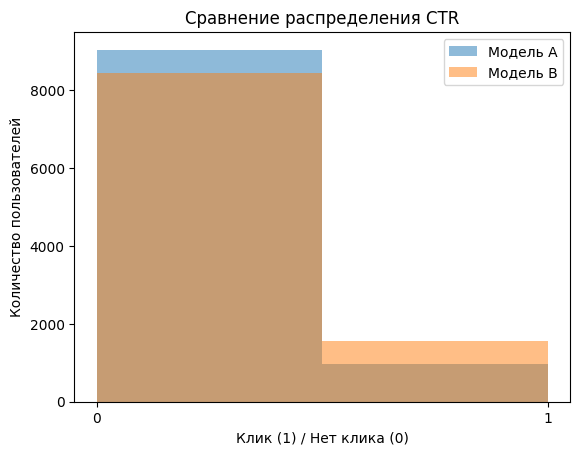

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

n_users = 10000

# Пусть CTR - вероятность клика
ctr_A = np.random.binomial(1, 0.10, n_users)
ctr_B = np.random.binomial(1, 0.15, n_users)

mean_A = np.mean(ctr_A)
mean_B = np.mean(ctr_B)

print(f'Средний CTR модели A: {mean_A}')
print(f'Средний CTR модели B: {mean_B}')

t_stat, p_value = stats.ttest_ind(ctr_A, ctr_B)

print(f'\nT-статистика: {t_stat}')
print(f'P-value: {p_value}')

alpha = 0.05

if p_value < alpha:
    print('\nРазличие статистически значимо (p < 0.05)')
else:
    print('\nСтатистически значимого различия нет')

plt.hist(ctr_A, bins=2, alpha=0.5, label='Модель A')
plt.hist(ctr_B, bins=2, alpha=0.5, label='Модель B')
plt.xticks([0, 1])
plt.xlabel('Клик (1) / Нет клика (0)')
plt.ylabel('Количество пользователей')
plt.title('Сравнение распределения CTR')
plt.legend()
plt.show()